In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

In [2]:
from google.colab import files
uploaded = files.upload()

Saving data (1).csv to data (1).csv


In [5]:
df = pd.read_csv("data (1).csv")

In [6]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [7]:
print(df.shape)

df.info()

(569, 33)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se    

In [8]:
df = df.drop(["id", "Unnamed: 32"], axis=1)

In [9]:
df["diagnosis"] = df["diagnosis"].map({
    "M":1,
    "B":0
})

In [10]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [13]:
X = df.drop(
    "diagnosis",
    axis=1
)

y = df["diagnosis"]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
scaler = StandardScaler()

X_train = scaler.fit_transform(
    X_train
)

X_test = scaler.transform(
    X_test
)

In [16]:
n_features = X_train.shape[1]

weights = np.zeros(
    n_features
)

bias = 0

In [17]:
def sigmoid(z):

    return 1 / (
        1 + np.exp(-z)
    )

In [18]:
def predict_probability(
        X,
        weights,
        bias):

    linear = (
        np.dot(X, weights)
        + bias
    )

    return sigmoid(linear)

In [19]:
def compute_cost(
        y,
        y_pred):

    m = len(y)

    cost = -(1/m) * np.sum(
        y*np.log(y_pred)
        +
        (1-y)*np.log(
            1-y_pred
        )
    )

    return cost

In [20]:
def compute_gradients(
        X,
        y,
        y_pred):

    m = len(y)

    dw = (
        1/m
    ) * np.dot(
        X.T,
        (y_pred-y)
    )

    db = (
        1/m
    ) * np.sum(
        y_pred-y
    )

    return dw, db

In [21]:
def gradient_descent(
        X,
        y,
        weights,
        bias,
        learning_rate,
        iterations):

    costs = []

    for i in range(
            iterations):

        y_pred = predict_probability(
            X,
            weights,
            bias
        )

        cost = compute_cost(
            y,
            y_pred
        )

        dw, db = compute_gradients(
            X,
            y,
            y_pred
        )

        weights = (
            weights
            - learning_rate * dw
        )

        bias = (
            bias
            - learning_rate * db
        )

        costs.append(cost)

    return (
        weights,
        bias,
        costs
    )

In [22]:
learning_rate = 0.01

iterations = 1000

In [23]:
weights, bias, costs = gradient_descent(
    X_train,
    y_train,
    weights,
    bias,
    learning_rate,
    iterations
)

In [24]:
print(costs[:10])

[np.float64(0.6931471805599453), np.float64(0.6739353141133738), np.float64(0.6559064972215113), np.float64(0.6389797634212733), np.float64(0.6230762530014361), np.float64(0.6081203882106933), np.float64(0.5940406887627787), np.float64(0.5807702594879951), np.float64(0.5682470068174842), np.float64(0.5564136485513382)]


In [25]:
print(costs[-10:])

[np.float64(0.10741026752394012), np.float64(0.10737640213035614), np.float64(0.10734258892217342), np.float64(0.10730882776611476), np.float64(0.10727511852937743), np.float64(0.10724146107963121), np.float64(0.10720785528501607), np.float64(0.10717430101414015), np.float64(0.10714079813607746), np.float64(0.10710734652036596)]


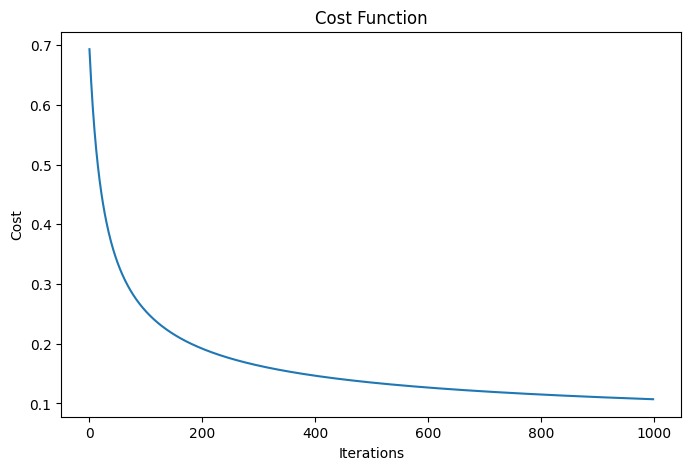

In [26]:
plt.figure(
    figsize=(8,5)
)

plt.plot(costs)

plt.xlabel(
    "Iterations"
)

plt.ylabel(
    "Cost"
)

plt.title(
    "Cost Function"
)

plt.show()

In [27]:
y_prob = predict_probability(
    X_test,
    weights,
    bias
)

In [28]:
print(
    y_prob[:10]
)

[0.20008858 0.99578318 0.93542023 0.03801915 0.00884864 0.99999831
 0.99997687 0.86925014 0.50122736 0.02388946]


In [29]:
y_pred = np.where(
    y_prob >= 0.5,
    1,
    0
)

In [30]:
accuracy = np.mean(
    y_pred == y_test
)

print(
    "Accuracy:",
    accuracy
)

Accuracy: 0.9824561403508771


In [31]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[70  1]
 [ 1 42]]


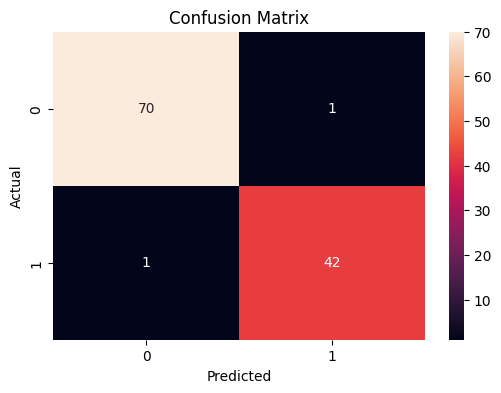

In [32]:
plt.figure(
    figsize=(6,4)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.title(
    "Confusion Matrix"
)

plt.show()

In [33]:
TP = cm[1,1]
TN = cm[0,0]
FP = cm[0,1]
FN = cm[1,0]

precision = TP / (TP + FP)

recall = TP / (TP + FN)

f1 = (
    2 * precision * recall
) / (
    precision + recall
)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.9767441860465116
Recall: 0.9767441860465116
F1 Score: 0.9767441860465116


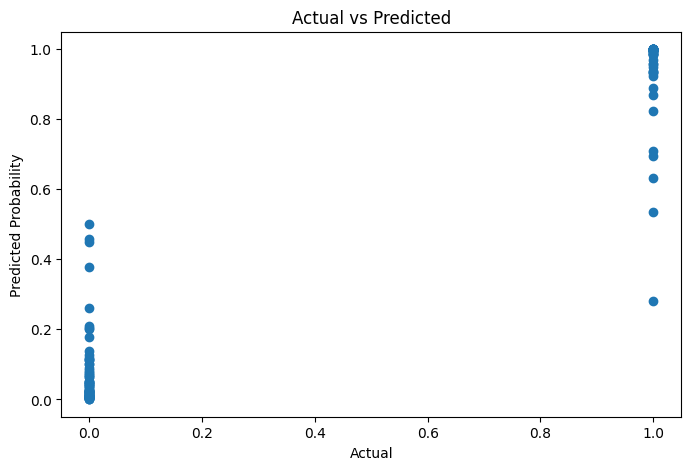

In [34]:
plt.figure(
    figsize=(8,5)
)

plt.scatter(
    y_test,
    y_prob
)

plt.xlabel(
    "Actual"
)

plt.ylabel(
    "Predicted Probability"
)

plt.title(
    "Actual vs Predicted"
)

plt.show()

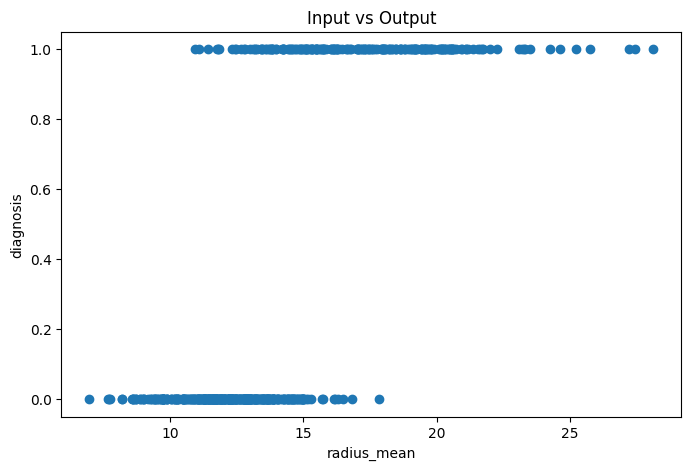

In [35]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["radius_mean"],
    df["diagnosis"]
)

plt.xlabel("radius_mean")
plt.ylabel("diagnosis")

plt.title("Input vs Output")

plt.show()